<a href="https://colab.research.google.com/github/ihdyrtg/data_science/blob/main/Analisis_Sentimen_Ulasan_Google_NotebookLM_dengan_Fine_Tuning_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Sentimen Ulasan Google NotebookLM dengan Fine-Tuning BERT

*   List item
*   List item

Multilingual

Notebook ini memperbaiki alur sebelumnya agar evaluasi benar-benar mengukur kemampuan generalisasi model, bukan sekadar membandingkan keluaran model siap pakai dengan seluruh data yang sama.

## Tujuan

1. Mengumpulkan dan mengaudit ulasan Google NotebookLM dari Google Play.
2. Memisahkan ulasan **Bahasa Indonesia** dan **Bahasa Inggris** berdasarkan deteksi bahasa aktual.
3. Membentuk label sentimen berbasis rating: 1–2 negatif, 3 netral, dan 4–5 positif.
4. Membuat **train–validation–test split 80:10:10** secara terstratifikasi untuk setiap bahasa.
5. Menangani ketidakseimbangan kelas hanya pada data train melalui **weighted cross-entropy loss** atau downsampling kelas positif.
6. Menghitung baseline sederhana sebelum fine-tuning BERT.
7. Melakukan fine-tuning backbone BERT multilingual yang sama secara **terpisah** untuk Bahasa Indonesia dan Inggris selama 3–5 epoch.
8. Membandingkan performa kedua model dengan macro F1, weighted F1, balanced accuracy, recall per kelas, PR-AUC, dan confusion matrix.

> **Catatan validitas:** rating pengguna dipakai sebagai *proxy label*, bukan anotasi sentimen manual. Karena itu, hasil penelitian harus ditulis sebagai prediksi sentimen berbasis rating, bukan sebagai kebenaran psikologis pengguna.

## 1. Instalasi paket

In [ ]:
# Jalankan sekali pada awal sesi Google Colab.
# Versi transformers dipatok agar API Trainer dan weighted loss konsisten.
!pip -q install \
    google-play-scraper==1.2.7 \
    transformers==4.51.1 \
    datasets==3.5.0 \
    accelerate==1.6.0 \
    langdetect==1.0.9 \
    scikit-learn \
    seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 741.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 62.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
gcsfs 2025.3.0 requires fsspec=

## 2. Konfigurasi eksperimen

In [ ]:
from pathlib import Path

# Reproduksibilitas
RANDOM_STATE = 42

# Sumber data: "scrape" atau "upload"
DATA_SOURCE = "scrape"
UPLOAD_FILENAME = "ulasan_notebooklm.csv"

# Scraping
APP_ID = "com.google.android.apps.labs.language.tailwind"
REVIEWS_PER_REGION = 3000
REGIONS = [
    {"source_language": "id", "region": "id"},
    {"source_language": "en", "region": "us"},
    {"source_language": "en", "region": "gb"},
    {"source_language": "en", "region": "ca"},
    {"source_language": "en", "region": "au"},
]

# Eksperimen BERT
BACKBONE = "bert-base-multilingual-uncased"
EPOCHS = 3                    # ubah menjadi 4 atau 5 bila diperlukan
MAX_LENGTH = 192
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

# Penanganan imbalance: "weighted_loss" atau "downsample_positive"
IMBALANCE_METHOD = "weighted_loss"

# Opsional untuk membatasi data saat uji coba cepat. None = seluruh data.
MAX_SAMPLES_PER_LANGUAGE = None

# Jika True, jumlah sampel Indonesia dan Inggris disamakan secara terstratifikasi.
# Ini lebih adil untuk eksperimen komparatif, tetapi membuang sebagian data bahasa yang lebih besar.
CONTROLLED_LANGUAGE_SAMPLE = False

OUTPUT_DIR = Path("/content/outputs_sentiment_bert")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_NAMES = ["Negatif", "Netral", "Positif"]
LABEL2ID = {name: idx for idx, name in enumerate(LABEL_NAMES)}
ID2LABEL = {idx: name for name, idx in LABEL2ID.items()}

print("Konfigurasi tersimpan di:", OUTPUT_DIR)

Konfigurasi tersimpan di: /content/outputs_sentiment_bert


## 3. Import, seed, dan informasi lingkungan

In [ ]:
import gc
import html
import json
import os
import random
import re
import sys
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch
import transformers

from langdetect import DetectorFactory, LangDetectException, detect
from sklearn.utils.class_weight import compute_class_weight
from transformers import set_seed

warnings.filterwarnings("ignore")
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
DetectorFactory.seed = RANDOM_STATE
set_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Python       :", sys.version.split()[0])
print("Pandas       :", pd.__version__)
print("Scikit-learn :", sklearn.__version__)
print("Transformers :", transformers.__version__)
print("PyTorch      :", torch.__version__)
print("Perangkat    :", DEVICE.upper())

if DEVICE != "cuda":
    print("PERINGATAN: aktifkan GPU melalui Runtime > Change runtime type > T4 GPU.")

Python       : 3.12.13
Pandas       : 2.2.2
Scikit-learn : 1.6.1
Transformers : 4.51.1
PyTorch      : 2.11.0+cpu
Perangkat    : CPU
PERINGATAN: aktifkan GPU melalui Runtime > Change runtime type > T4 GPU.


## 4. Memuat data

Notebook tidak mengumpulkan atau mengekspor nama pengguna. Kolom yang dipertahankan hanya rating, tanggal, teks ulasan, region sumber, dan bahasa sumber. Hal ini mengurangi risiko identitas pribadi masuk ke model atau artifact.

In [ ]:
from google_play_scraper import Sort, reviews


def scrape_reviews(app_id, regions, max_per_region=3000):
    rows = []
    for target in regions:
        region = target["region"]
        source_language = target["source_language"]
        continuation_token = None
        collected = 0
        print(f"Mengambil region {region.upper()} ({source_language}) ...")

        while collected < max_per_region:
            request_count = min(200, max_per_region - collected)
            try:
                batch, continuation_token = reviews(
                    app_id,
                    lang=source_language,
                    country=region,
                    sort=Sort.NEWEST,
                    count=request_count,
                    continuation_token=continuation_token,
                )
            except Exception as exc:
                print(f"  Berhenti pada {region.upper()}: {exc}")
                break

            if not batch:
                break

            for item in batch:
                rows.append({
                    "review_id": item.get("reviewId"),
                    "rating": item.get("score"),
                    "date": item.get("at"),
                    "review": item.get("content"),
                    "source_region": region,
                    "source_language": source_language,
                })

            collected += len(batch)
            if not continuation_token:
                break
            time.sleep(0.8)

        print(f"  Terkumpul sementara: {collected}")

    return pd.DataFrame(rows)


if DATA_SOURCE == "scrape":
    df_raw = scrape_reviews(APP_ID, REGIONS, REVIEWS_PER_REGION)
else:
    from google.colab import files
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("Tidak ada berkas yang diunggah.")
    filename = UPLOAD_FILENAME if UPLOAD_FILENAME in uploaded else next(iter(uploaded))
    df_raw = pd.read_csv(filename)

required = {"rating", "review"}
missing = required - set(df_raw.columns)
if missing:
    raise KeyError(f"Kolom wajib tidak ditemukan: {sorted(missing)}")

for optional_col, default_value in {
    "review_id": None,
    "date": pd.NaT,
    "source_region": "unknown",
    "source_language": "unknown",
}.items():
    if optional_col not in df_raw.columns:
        df_raw[optional_col] = default_value

print("Ukuran data mentah:", df_raw.shape)
display(df_raw[["rating", "date", "review", "source_region", "source_language"]].head())

Mengambil region ID (id) ...
  Terkumpul sementara: 623
Mengambil region US (en) ...
  Terkumpul sementara: 3000
Mengambil region GB (en) ...
  Terkumpul sementara: 3000
Mengambil region CA (en) ...
  Terkumpul sementara: 3000
Mengambil region AU (en) ...
  Terkumpul sementara: 3000
Ukuran data mentah: (12623, 6)


,rating,date,review,source_region,source_language
0,4,2026-07-27 23:21:29,sangat puasss,id,id
1,1,2026-07-27 14:24:06,"aplikasi sering kali bug, taxt pesan saya hila...",id,id
2,5,2026-07-27 13:41:03,aplikasi ini sangat membantu saya dalam memaha...,id,id
3,5,2026-07-27 10:00:38,bagus,id,id
4,1,2026-07-26 07:53:46,punten ini teh bug atau gimana yh ini pas saya...,id,id


## 5. Pembersihan minimal, anonimisasi, dan deteksi bahasa aktual

In [ ]:
EMAIL_RE = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
PHONE_RE = re.compile(r"(?<!\d)(?:\+?\d[\d\s().-]{7,}\d)(?!\d)")
URL_RE = re.compile(r"https?://\S+|www\.\S+", re.I)
HTML_RE = re.compile(r"<[^>]+>")
SPACE_RE = re.compile(r"\s+")


def clean_review(text):
    """Pembersihan minimal untuk BERT; tanda baca dan karakter Unicode tetap dipertahankan."""
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = HTML_RE.sub(" ", text)
    text = EMAIL_RE.sub(" [EMAIL] ", text)
    text = PHONE_RE.sub(" [PHONE] ", text)
    text = URL_RE.sub(" [URL] ", text)
    return SPACE_RE.sub(" ", text).strip()


def detect_language_safe(text, fallback="unknown"):
    if not isinstance(text, str) or len(text.strip()) < 3:
        return fallback
    try:
        return detect(text)
    except LangDetectException:
        return fallback


df = df_raw.copy()
df["text"] = df["review"].map(clean_review)
df = df[df["text"].str.len() >= 3].copy()
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df[df["rating"].between(1, 5)].copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Deteksi bahasa berdasarkan teks, bukan semata-mata region Play Store.
df["detected_language"] = [
    detect_language_safe(text, fallback=source)
    for text, source in zip(df["text"], df["source_language"])
]

# Hanya dua bahasa yang menjadi ruang lingkup penelitian.
df = df[df["detected_language"].isin(["id", "en"])].copy()

# Normalisasi dipakai hanya untuk menghapus duplikat lintas region sebelum split.
df["text_key"] = (
    df["text"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
)

before = len(df)
if df["review_id"].notna().any():
    df = df.sort_values("date", ascending=False).drop_duplicates(subset=["review_id"], keep="first")
df = df.drop_duplicates(subset=["text_key"], keep="first")
print("Duplikat yang dibuang:", before - len(df))

# Label berbasis rating sebagai proxy ground truth.
def rating_to_label(rating):
    if rating <= 2:
        return 0
    if rating == 3:
        return 1
    return 2


df["label"] = df["rating"].map(rating_to_label).astype(int)
df["sentiment"] = df["label"].map(ID2LABEL)

# Tidak mengekspor review_id atau identitas akun.
df_anonymous = df[[
    "rating", "date", "text", "source_region", "source_language",
    "detected_language", "label", "sentiment"
]].copy()
df_anonymous.to_csv(OUTPUT_DIR / "dataset_anonymous.csv", index=False, encoding="utf-8-sig")

print("Ukuran setelah pembersihan:", df.shape)
display(df_anonymous.head())

Duplikat yang dibuang: 6577
Ukuran setelah pembersihan: (2511, 11)


,rating,date,text,source_region,source_language,detected_language,label,sentiment
6624,5,2026-07-28 00:54:48,I personally love the Gemini AI system. Notebo...,ca,en,en,2,Positif
9625,5,2026-07-28 00:27:17,"great features, easy to navigate, requires 0 e...",au,en,en,2,Positif
626,4,2026-07-27 22:07:41,it's helpful. i can make podcasts from my book...,us,en,en,2,Positif
9627,5,2026-07-27 21:39:57,App could use some buffering so that Audio pla...,au,en,en,2,Positif
9628,4,2026-07-27 21:15:48,"This is an amazing app! However, not every fea...",au,en,en,2,Positif


## 6. Audit kualitas data dan ketidakseimbangan kelas

,dtype,missing_n,missing_pct,unique_n
rating,int64,0,0.0,5
date,datetime64[ns],0,0.0,2511
text,object,0,0.0,2511
source_region,object,0,0.0,5
source_language,object,0,0.0,2
detected_language,object,0,0.0,2
label,int64,0,0.0,3
sentiment,object,0,0.0,3


Distribusi kelas per bahasa:


sentiment,Negatif,Netral,Positif
detected_language,,,
en,267,110,1734
id,41,11,348


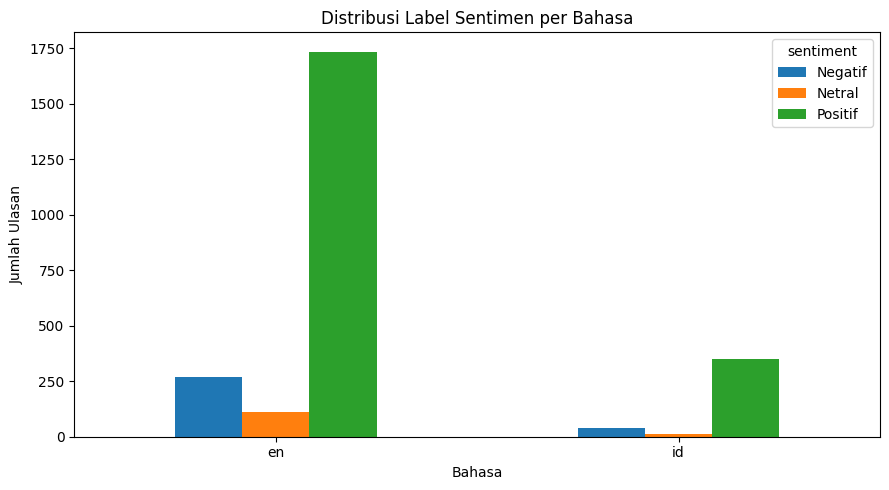

In [ ]:
audit = pd.DataFrame({
    "dtype": df_anonymous.dtypes.astype(str),
    "missing_n": df_anonymous.isna().sum(),
    "missing_pct": (df_anonymous.isna().mean() * 100).round(2),
    "unique_n": df_anonymous.nunique(dropna=True),
})
display(audit)

language_counts = pd.crosstab(
    df_anonymous["detected_language"],
    df_anonymous["sentiment"],
).reindex(columns=LABEL_NAMES, fill_value=0)

print("Distribusi kelas per bahasa:")
display(language_counts)

ax = language_counts.plot(kind="bar", figsize=(9, 5))
ax.set_title("Distribusi Label Sentimen per Bahasa")
ax.set_xlabel("Bahasa")
ax.set_ylabel("Jumlah Ulasan")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution_by_language.png", dpi=200)
plt.show()

for language in ["id", "en"]:
    counts = df.loc[df["detected_language"] == language, "label"].value_counts().reindex([0, 1, 2], fill_value=0)
    if (counts < 10).any():
        print(f"PERINGATAN {language}: ada kelas dengan kurang dari 10 observasi: {counts.to_dict()}")

## 7. Menyiapkan dataset per bahasa

Pemisahan bahasa dilakukan **sebelum** train–validation–test split. Kedua bahasa tidak pernah dimasukkan ke ember evaluasi yang sama. Backbone model sama, tetapi proses fine-tuning dan artifact model dibuat terpisah.

In [ ]:
from sklearn.model_selection import train_test_split


def stratified_cap(data, n_samples):
    if n_samples is None or len(data) <= n_samples:
        return data.copy()
    selected, _ = train_test_split(
        data,
        train_size=n_samples,
        stratify=data["label"],
        random_state=RANDOM_STATE,
    )
    return selected.copy()


language_data = {
    language: df[df["detected_language"] == language].copy()
    for language in ["id", "en"]
}

if MAX_SAMPLES_PER_LANGUAGE is not None:
    language_data = {
        language: stratified_cap(data, MAX_SAMPLES_PER_LANGUAGE)
        for language, data in language_data.items()
    }

if CONTROLLED_LANGUAGE_SAMPLE:
    common_n = min(len(data) for data in language_data.values())
    language_data = {
        language: stratified_cap(data, common_n)
        for language, data in language_data.items()
    }
    print("Mode perbandingan terkontrol. Sampel per bahasa:", common_n)

for language, data in language_data.items():
    counts = data["label"].value_counts().reindex([0, 1, 2], fill_value=0)
    if (counts < 5).any():
        raise ValueError(
            f"Bahasa {language} tidak memiliki cukup data untuk stratified split 80:10:10. "
            f"Distribusi: {counts.to_dict()}"
        )
    print(language, len(data), counts.to_dict())

id 400 {0: 41, 1: 11, 2: 348}
en 2111 {0: 267, 1: 110, 2: 1734}


## 8. Train–validation–test split 80:10:10 dan penanganan imbalance hanya pada train set

In [ ]:
def split_80_10_10(data):
    train_df, temp_df = train_test_split(
        data,
        test_size=0.20,
        stratify=data["label"],
        random_state=RANDOM_STATE,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df["label"],
        random_state=RANDOM_STATE,
    )
    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


def downsample_positive_only(train_df):
    """Mengurangi kelas positif hingga setara dengan kelas negatif; kelas netral tidak disentuh."""
    negative = train_df[train_df["label"] == 0]
    neutral = train_df[train_df["label"] == 1]
    positive = train_df[train_df["label"] == 2]

    target_positive_n = min(len(positive), len(negative))
    positive_sample = positive.sample(n=target_positive_n, random_state=RANDOM_STATE)
    balanced = pd.concat([negative, neutral, positive_sample], ignore_index=True)
    return balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)


def calculate_class_weights(train_df):
    classes = np.array([0, 1, 2])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=train_df["label"].to_numpy(),
    )
    return torch.tensor(weights, dtype=torch.float)


splits = {}
for language, data in language_data.items():
    train_df, val_df, test_df = split_80_10_10(data)

    original_train_counts = train_df["label"].value_counts().reindex([0, 1, 2], fill_value=0)

    if IMBALANCE_METHOD == "downsample_positive":
        train_model_df = downsample_positive_only(train_df)
        class_weights = torch.ones(3, dtype=torch.float)
    elif IMBALANCE_METHOD == "weighted_loss":
        train_model_df = train_df.copy()
        class_weights = calculate_class_weights(train_model_df)
    else:
        raise ValueError("IMBALANCE_METHOD harus 'weighted_loss' atau 'downsample_positive'.")

    splits[language] = {
        "train_original": train_df,
        "train": train_model_df,
        "val": val_df,
        "test": test_df,
        "class_weights": class_weights,
    }

    print(f"\nBahasa {language.upper()}")
    print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))
    print("Distribusi train asli:", original_train_counts.to_dict())
    print("Distribusi train model:", train_model_df["label"].value_counts().reindex([0,1,2], fill_value=0).to_dict())
    print("Class weights:", class_weights.tolist())

    # Verifikasi bahwa test set tidak disentuh oleh resampling.
    assert len(test_df) == len(splits[language]["test"])


Bahasa ID
Train/Val/Test: 320 40 40
Distribusi train asli: {0: 33, 1: 9, 2: 278}
Distribusi train model: {0: 33, 1: 9, 2: 278}
Class weights: [3.232323169708252, 11.851851463317871, 0.38369303941726685]

Bahasa EN
Train/Val/Test: 1688 211 212
Distribusi train asli: {0: 213, 1: 88, 2: 1387}
Distribusi train model: {0: 213, 1: 88, 2: 1387}
Class weights: [2.641627550125122, 6.39393949508667, 0.40567171573638916]


## 9. Baseline: Dummy dan TF-IDF + Logistic Regression

Baseline diperlukan agar BERT tidak disebut “baik” hanya karena angka akurasinya tampak tinggi. BERT harus mengungguli tebakan kelas mayoritas dan model teks klasik yang jauh lebih sederhana.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline

comparison_rows = []
baseline_predictions = {}


def metric_row(language, model_name, y_true, y_pred):
    return {
        "language": language,
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


for language, parts in splits.items():
    train_df = parts["train"]
    test_df = parts["test"]

    X_train = train_df["text"]
    y_train = train_df["label"]
    X_test = test_df["text"]
    y_test = test_df["label"]

    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(np.zeros((len(y_train), 1)), y_train)
    dummy_pred = dummy.predict(np.zeros((len(y_test), 1)))
    comparison_rows.append(metric_row(language, "Dummy majority", y_test, dummy_pred))

    tfidf_logreg = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_features=50000,
            sublinear_tf=True,
        )),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced" if IMBALANCE_METHOD == "weighted_loss" else None,
            random_state=RANDOM_STATE,
        )),
    ])
    tfidf_logreg.fit(X_train, y_train)
    tfidf_pred = tfidf_logreg.predict(X_test)
    comparison_rows.append(metric_row(language, "TF-IDF + Logistic", y_test, tfidf_pred))
    baseline_predictions[language] = tfidf_pred

    print(f"\nBaseline TF-IDF — {language.upper()}")
    print(classification_report(y_test, tfidf_pred, target_names=LABEL_NAMES, zero_division=0))


Baseline TF-IDF — ID
              precision    recall  f1-score   support

     Negatif       0.50      1.00      0.67         4
      Netral       0.00      0.00      0.00         1
     Positif       1.00      0.86      0.92        35

    accuracy                           0.85        40
   macro avg       0.50      0.62      0.53        40
weighted avg       0.93      0.85      0.87        40


Baseline TF-IDF — EN
              precision    recall  f1-score   support

     Negatif       0.48      0.52      0.50        27
      Netral       0.22      0.36      0.28        11
     Positif       0.91      0.86      0.88       174

    accuracy                           0.79       212
   macro avg       0.54      0.58      0.55       212
weighted avg       0.82      0.79      0.80       212



## 10. Menyiapkan tokenizer, dataset Hugging Face, dan metrik

In [ ]:
from datasets import Dataset
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize
from transformers import AutoTokenizer, DataCollatorWithPadding


tokenizer = AutoTokenizer.from_pretrained(BACKBONE)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def to_hf_dataset(frame):
    subset = frame[["text", "label"]].rename(columns={"label": "labels"}).copy()
    ds = Dataset.from_pandas(subset, preserve_index=False)

    def tokenize_batch(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=MAX_LENGTH,
        )

    return ds.map(tokenize_batch, batched=True, remove_columns=["text"])


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    probabilities = torch.softmax(torch.tensor(logits), dim=1).numpy()
    labels_binary = label_binarize(labels, classes=[0, 1, 2])

    return {
        "accuracy": accuracy_score(labels, predictions),
        "balanced_accuracy": balanced_accuracy_score(labels, predictions),
        "macro_precision": precision_score(labels, predictions, average="macro", zero_division=0),
        "macro_recall": recall_score(labels, predictions, average="macro", zero_division=0),
        "macro_f1": f1_score(labels, predictions, average="macro", zero_division=0),
        "weighted_f1": f1_score(labels, predictions, average="weighted", zero_division=0),
        "macro_pr_auc": average_precision_score(labels_binary, probabilities, average="macro"),
    }

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## 11. Fine-tuning BERT terpisah per bahasa

- Model Indonesia hanya melihat train dan validation Bahasa Indonesia.
- Model Inggris hanya melihat train dan validation Bahasa Inggris.
- Test set baru dipakai setelah model terbaik dipilih berdasarkan **validation macro F1**.
- Weighted cross-entropy dihitung dari distribusi kelas pada **train set saja**.

In [ ]:
from torch import nn
from transformers import (
    AutoModelForSequenceClassification,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)


class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        weights = self.class_weights.to(model.device)
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


trainers = {}
bert_test_outputs = {}

for language, parts in splits.items():
    print("\n" + "=" * 80)
    print(f"FINE-TUNING BERT — {language.upper()}")
    print("=" * 80)

    train_ds = to_hf_dataset(parts["train"])
    val_ds = to_hf_dataset(parts["val"])
    test_ds = to_hf_dataset(parts["test"])

    model = AutoModelForSequenceClassification.from_pretrained(
        BACKBONE,
        num_labels=3,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )

    language_output = OUTPUT_DIR / f"bert_{language}"
    args = TrainingArguments(
        output_dir=str(language_output),
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=EPOCHS,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
        fp16=torch.cuda.is_available(),
        seed=RANDOM_STATE,
        data_seed=RANDOM_STATE,
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=data_collator,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
        class_weights=parts["class_weights"],
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()
    test_output = trainer.predict(test_ds)

    model_dir = OUTPUT_DIR / f"final_model_{language}"
    trainer.save_model(model_dir)
    tokenizer.save_pretrained(model_dir)

    trainers[language] = trainer
    bert_test_outputs[language] = test_output

    # Bebaskan cache sebelum bahasa berikutnya.
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


FINE-TUNING BERT — ID


Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

...

Map:   0%|          | 0/1688 [00:00<?, ? examples/s]

Map:   0%|          | 0/211 [00:00<?, ? examples/s]

Map:   0%|          | 0/212 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Macro Pr Auc
1,0.869000,0.899802,0.715640,0.551417,0.429945,0.551417,0.441176,0.739197,0.528946
2,0.735100,1.016284,0.862559,0.602505,0.637128,0.602505,0.618163,0.858298,0.636036
3,0.559100,0.922506,0.848341,0.617563,0.597351,0.617563,0.606174,0.853842,0.639601


## 12. Evaluasi final test set per bahasa

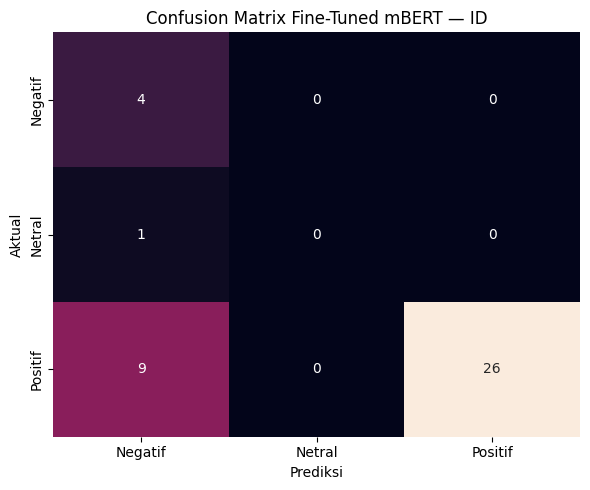


Classification report — ID


,precision,recall,f1-score,support
Negatif,0.285714,1.000000,0.444444,4.00
Netral,0.000000,0.000000,0.000000,1.00
Positif,1.000000,0.742857,0.852459,35.00
accuracy,0.750000,0.750000,0.750000,0.75
macro avg,0.428571,0.580952,0.432301,40.00
weighted avg,0.903571,0.750000,0.790346,40.00


Contoh kesalahan dengan confidence tertinggi:


,rating,date,text,sentiment,predicted_label,predicted_sentiment,prob_negative,prob_neutral,prob_positive,confidence,correct
26,4,2026-07-17 23:30:34,infografis nya knp ga bisa dipakeee??,Positif,0,Negatif,0.455732,0.150912,0.393356,0.455732,False
7,4,2025-09-18 07:42:09,cara setting bahasa gimana? tiba tiba banget p...,Positif,0,Negatif,0.455575,0.122407,0.422017,0.455575,False
18,4,2026-04-18 20:12:37,tools yang keren tapi minusnya tidak ada tombo...,Positif,0,Negatif,0.445787,0.178949,0.375265,0.445787,False
32,5,2026-07-25 03:37:52,"Sangat membantu, dan juga saya sangat terbantu...",Positif,0,Negatif,0.439283,0.169204,0.391513,0.439283,False
0,5,2025-05-19 23:26:31,"aplikasinya bagus dan saya suka, kekurangannya...",Positif,0,Negatif,0.437041,0.190515,0.372444,0.437041,False
14,5,2026-07-02 13:26:22,sangat bagus dan mudah dimengerti serta masuk ...,Positif,0,Negatif,0.436457,0.146175,0.417369,0.436457,False
29,3,2026-03-12 20:25:35,ppt tdk bisa di download,Netral,0,Negatif,0.434396,0.172761,0.392844,0.434396,False
8,5,2026-06-14 06:26:29,cara download hasilnya bagaimana? di PC bisa t...,Positif,0,Negatif,0.421342,0.213766,0.364892,0.421342,False
37,4,2026-02-09 11:24:33,sudah bagus tapi mohon untuk diberikan fitur d...,Positif,0,Negatif,0.410756,0.187636,0.401609,0.410756,False
2,5,2026-02-21 02:53:17,butuh peningkatan dalam menampilkan hasil stud...,Positif,0,Negatif,0.396081,0.236476,0.367442,0.396081,False


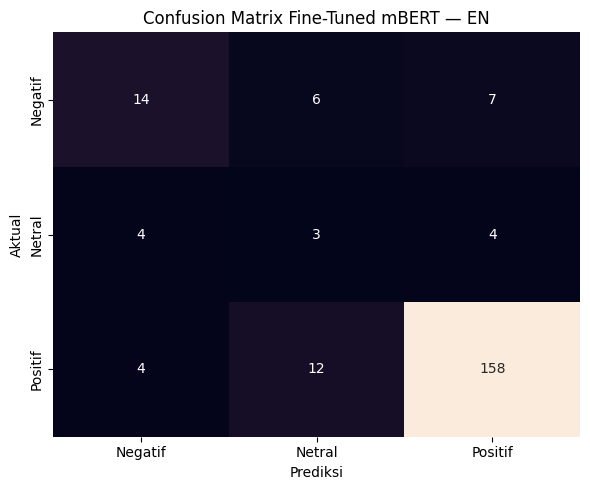


Classification report — EN


,precision,recall,f1-score,support
Negatif,0.636364,0.518519,0.571429,27.000000
Netral,0.142857,0.272727,0.187500,11.000000
Positif,0.934911,0.908046,0.921283,174.000000
accuracy,0.825472,0.825472,0.825472,0.825472
macro avg,0.571377,0.566431,0.560070,212.000000
weighted avg,0.855792,0.825472,0.838652,212.000000


Contoh kesalahan dengan confidence tertinggi:


,rating,date,text,sentiment,predicted_label,predicted_sentiment,prob_negative,prob_neutral,prob_positive,confidence,correct
102,3,2026-07-14 17:30:41,very useful app,Netral,2,Positif,0.017674,0.026707,0.955619,0.955619,False
144,3,2026-06-06 08:39:52,really helpful,Netral,2,Positif,0.021020,0.025028,0.953952,0.953952,False
191,2,2026-06-07 12:23:34,💃🏻💃🏻,Negatif,2,Positif,0.026497,0.033585,0.939918,0.939918,False
177,1,2026-07-22 17:42:35,trd class,Negatif,2,Positif,0.036187,0.061150,0.902662,0.902662,False
25,2,2026-05-22 16:28:56,It's phenomenal as other AI tools are with the...,Negatif,2,Positif,0.026448,0.125769,0.847783,0.847783,False
53,2,2026-06-22 10:29:35,how can I use the dang app when you hide the s...,Negatif,2,Positif,0.045653,0.110416,0.843931,0.843931,False
135,1,2026-07-21 15:43:38,Just use ChatGPT.,Negatif,2,Positif,0.068773,0.088464,0.842763,0.842763,False
103,3,2026-03-05 21:25:44,I'm quite sad because the features of free aud...,Netral,2,Positif,0.059419,0.136203,0.804377,0.804377,False
44,3,2026-06-03 15:14:10,can't share notebooks on android app,Netral,0,Negatif,0.697047,0.270035,0.032918,0.697047,False
120,3,2026-07-25 14:50:39,"Suddenly, tables can't be generated. Text are ...",Netral,0,Negatif,0.661948,0.307432,0.030620,0.661948,False


In [ ]:
from sklearn.metrics import confusion_matrix


def evaluate_bert_test(language, test_df, prediction_output):
    logits = prediction_output.predictions
    y_true = test_df["label"].to_numpy()
    y_pred = np.argmax(logits, axis=-1)
    probabilities = torch.softmax(torch.tensor(logits), dim=1).numpy()
    labels_binary = label_binarize(y_true, classes=[0, 1, 2])

    row = metric_row(language, "Fine-tuned mBERT", y_true, y_pred)
    row["macro_pr_auc"] = average_precision_score(labels_binary, probabilities, average="macro")

    report = classification_report(
        y_true,
        y_pred,
        target_names=LABEL_NAMES,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    report_df.to_csv(OUTPUT_DIR / f"classification_report_{language}.csv", encoding="utf-8-sig")

    pred_df = test_df[["rating", "date", "text", "sentiment"]].copy()
    pred_df["predicted_label"] = y_pred
    pred_df["predicted_sentiment"] = [ID2LABEL[int(x)] for x in y_pred]
    pred_df["prob_negative"] = probabilities[:, 0]
    pred_df["prob_neutral"] = probabilities[:, 1]
    pred_df["prob_positive"] = probabilities[:, 2]
    pred_df["confidence"] = probabilities.max(axis=1)
    pred_df["correct"] = pred_df["predicted_label"] == y_true
    pred_df.to_csv(OUTPUT_DIR / f"test_predictions_{language}.csv", index=False, encoding="utf-8-sig")

    error_df = pred_df[~pred_df["correct"]].sort_values("confidence", ascending=False)
    error_df.to_csv(OUTPUT_DIR / f"error_analysis_{language}.csv", index=False, encoding="utf-8-sig")

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False,
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES,
    )
    plt.title(f"Confusion Matrix Fine-Tuned mBERT — {language.upper()}")
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"confusion_matrix_{language}.png", dpi=200)
    plt.show()

    print(f"\nClassification report — {language.upper()}")
    display(report_df)
    print("Contoh kesalahan dengan confidence tertinggi:")
    display(error_df.head(10))

    return row, pred_df


bert_prediction_frames = {}
for language, output in bert_test_outputs.items():
    row, pred_frame = evaluate_bert_test(language, splits[language]["test"], output)
    comparison_rows.append(row)
    bert_prediction_frames[language] = pred_frame

## 13. Perbandingan performa Indonesia vs Inggris dan baseline

,language,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_pr_auc
5,en,Fine-tuned mBERT,0.8255,0.5664,0.5714,0.5664,0.5601,0.8387,0.6275
3,en,TF-IDF + Logistic,0.7925,0.5814,0.5380,0.5814,0.5536,0.8043,NaN
2,en,Dummy majority,0.8208,0.3333,0.2736,0.3333,0.3005,0.7400,NaN
1,id,TF-IDF + Logistic,0.8500,0.6190,0.5000,0.6190,0.5299,0.8744,NaN
4,id,Fine-tuned mBERT,0.7500,0.5810,0.4286,0.5810,0.4323,0.7903,0.6512
0,id,Dummy majority,0.8750,0.3333,0.2917,0.3333,0.3111,0.8167,NaN


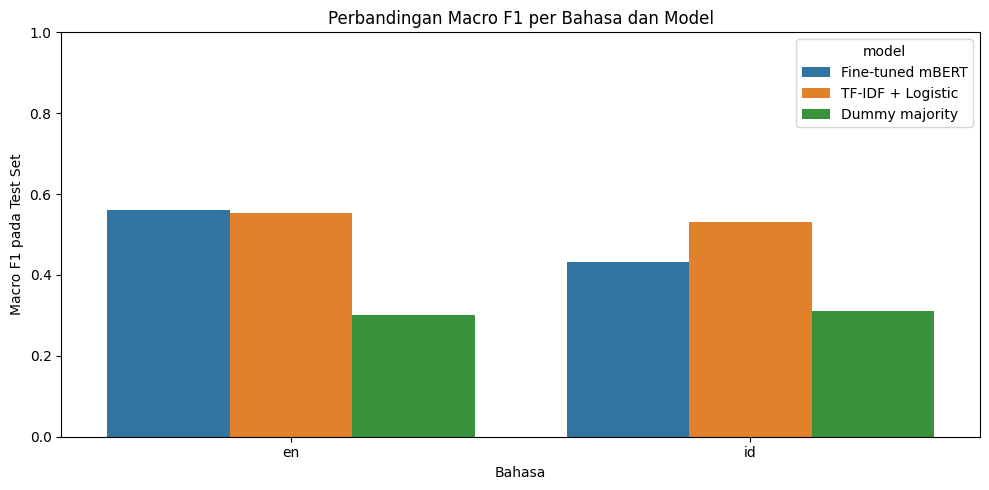

Ringkasan komparatif BERT:


,language,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_pr_auc
5,en,Fine-tuned mBERT,0.8255,0.5664,0.5714,0.5664,0.5601,0.8387,0.6275
4,id,Fine-tuned mBERT,0.7500,0.5810,0.4286,0.5810,0.4323,0.7903,0.6512


PERINGATAN INTERPRETASI: jumlah sampel kedua bahasa tidak dikontrol. Perbedaan performa tidak boleh langsung dianggap sebagai efek bahasa karena juga dapat dipengaruhi ukuran data, distribusi kelas, panjang ulasan, dan kualitas proxy label.


In [ ]:
comparison = pd.DataFrame(comparison_rows)
metric_columns = [
    "language", "model", "accuracy", "balanced_accuracy",
    "macro_precision", "macro_recall", "macro_f1", "weighted_f1", "macro_pr_auc"
]
for col in metric_columns:
    if col not in comparison.columns:
        comparison[col] = np.nan

comparison = comparison[metric_columns].sort_values(["language", "macro_f1"], ascending=[True, False])
comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig")
display(comparison.round(4))

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison, x="language", y="macro_f1", hue="model")
plt.ylim(0, 1)
plt.title("Perbandingan Macro F1 per Bahasa dan Model")
plt.xlabel("Bahasa")
plt.ylabel("Macro F1 pada Test Set")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "macro_f1_comparison.png", dpi=200)
plt.show()

bert_only = comparison[comparison["model"] == "Fine-tuned mBERT"].copy()
print("Ringkasan komparatif BERT:")
display(bert_only.round(4))

if not CONTROLLED_LANGUAGE_SAMPLE:
    print(
        "PERINGATAN INTERPRETASI: jumlah sampel kedua bahasa tidak dikontrol. "
        "Perbedaan performa tidak boleh langsung dianggap sebagai efek bahasa karena juga dapat dipengaruhi "
        "ukuran data, distribusi kelas, panjang ulasan, dan kualitas proxy label."
    )

## 14. Kurva pelatihan dan pemeriksaan overfitting

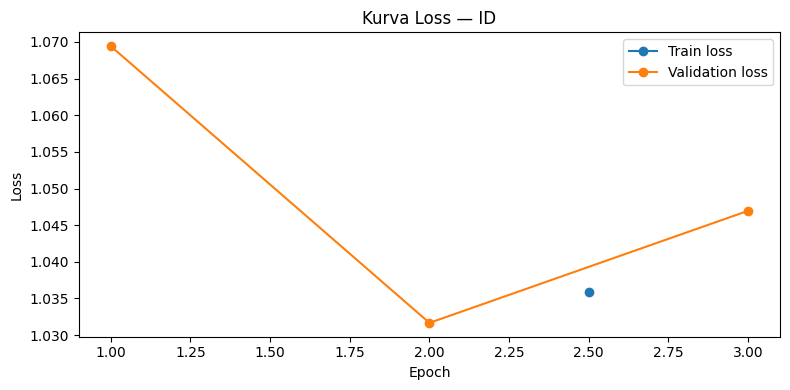

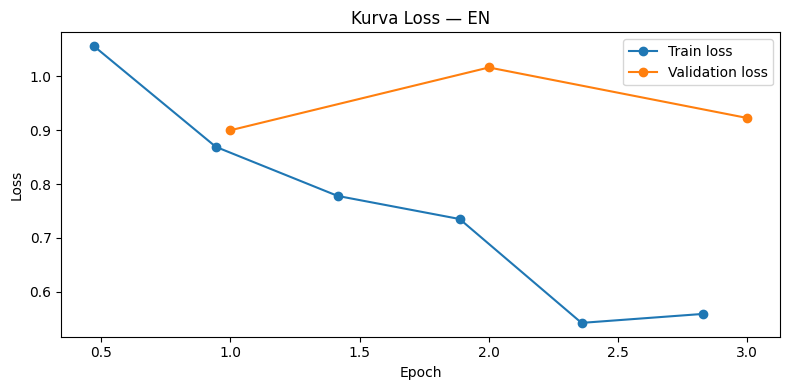

In [ ]:
for language, trainer in trainers.items():
    history = pd.DataFrame(trainer.state.log_history)
    history.to_csv(OUTPUT_DIR / f"training_history_{language}.csv", index=False)

    train_loss = history.dropna(subset=["loss"])[["epoch", "loss"]] if "loss" in history else pd.DataFrame()
    eval_loss = history.dropna(subset=["eval_loss"])[["epoch", "eval_loss"]] if "eval_loss" in history else pd.DataFrame()

    plt.figure(figsize=(8, 4))
    if not train_loss.empty:
        plt.plot(train_loss["epoch"], train_loss["loss"], marker="o", label="Train loss")
    if not eval_loss.empty:
        plt.plot(eval_loss["epoch"], eval_loss["eval_loss"], marker="o", label="Validation loss")
    plt.title(f"Kurva Loss — {language.upper()}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"loss_curve_{language}.png", dpi=200)
    plt.show()

## 15. Metadata, artifact, dan unduhan

In [ ]:
run_metadata = {
    "app_id": APP_ID,
    "backbone": BACKBONE,
    "random_state": RANDOM_STATE,
    "split": {"train": 0.80, "validation": 0.10, "test": 0.10},
    "epochs": EPOCHS,
    "max_length": MAX_LENGTH,
    "learning_rate": LEARNING_RATE,
    "imbalance_method": IMBALANCE_METHOD,
    "controlled_language_sample": CONTROLLED_LANGUAGE_SAMPLE,
    "max_samples_per_language": MAX_SAMPLES_PER_LANGUAGE,
    "label_definition": {"1-2": "Negatif", "3": "Netral", "4-5": "Positif"},
    "sample_sizes": {lang: len(data) for lang, data in language_data.items()},
    "package_versions": {
        "python": sys.version.split()[0],
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "transformers": transformers.__version__,
        "torch": torch.__version__,
    },
}

with open(OUTPUT_DIR / "run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, ensure_ascii=False, indent=2, default=str)

print("Artifact yang dihasilkan:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print("-", path.relative_to(OUTPUT_DIR))

# Satukan seluruh hasil untuk diunduh.
import shutil
archive_path = shutil.make_archive("hasil_analisis_sentimen_bert", "zip", OUTPUT_DIR)
print("Arsip:", archive_path)

# Aktifkan dua baris berikut bila ingin langsung mengunduh hasil.
# from google.colab import files
# files.download(archive_path)

Artifact yang dihasilkan:
- bert_en/checkpoint-212/config.json
- bert_en/checkpoint-212/model.safetensors
- bert_en/checkpoint-212/optimizer.pt
- bert_en/checkpoint-212/rng_state.pth
- bert_en/checkpoint-212/scheduler.pt
- bert_en/checkpoint-212/special_tokens_map.json
- bert_en/checkpoint-212/tokenizer.json
- bert_en/checkpoint-212/tokenizer_config.json
- bert_en/checkpoint-212/trainer_state.json
- bert_en/checkpoint-212/training_args.bin
- bert_en/checkpoint-212/vocab.txt
- bert_id/checkpoint-40/config.json
- bert_id/checkpoint-40/model.safetensors
- bert_id/checkpoint-40/optimizer.pt
- bert_id/checkpoint-40/rng_state.pth
- bert_id/checkpoint-40/scheduler.pt
- bert_id/checkpoint-40/special_tokens_map.json
- bert_id/checkpoint-40/tokenizer.json
- bert_id/checkpoint-40/tokenizer_config.json
- bert_id/checkpoint-40/trainer_state.json
- bert_id/checkpoint-40/training_args.bin
- bert_id/checkpoint-40/vocab.txt
- class_distribution_by_language.png
- classification_report_en.csv
- classific

## 16. Panduan penulisan hasil akademik

### Metode

Dataset dibersihkan secara minimal tanpa stemming atau penghapusan tanda baca karena tokenisasi dilakukan oleh BERT. Ulasan dideteksi bahasanya dan hanya data Bahasa Indonesia serta Inggris yang dianalisis. Label sentimen diturunkan dari rating pengguna: rating 1–2 sebagai negatif, 3 sebagai netral, dan 4–5 sebagai positif. Setiap bahasa dipisahkan menjadi train, validation, dan test dengan rasio 80:10:10 menggunakan stratifikasi kelas. Ketidakseimbangan kelas ditangani hanya pada train set menggunakan weighted cross-entropy atau downsampling kelas positif. Model BERT multilingual yang sama kemudian di-fine-tune secara terpisah untuk masing-masing bahasa.

### Hasil yang wajib dilaporkan

1. Jumlah ulasan dan distribusi kelas per bahasa.
2. Jumlah data train, validation, dan test per bahasa.
3. Nilai class weight atau jumlah data setelah downsampling.
4. Performa Dummy, TF-IDF + Logistic Regression, dan fine-tuned mBERT.
5. Macro F1 sebagai metrik utama, disertai weighted F1, balanced accuracy, recall per kelas, PR-AUC, dan confusion matrix.
6. Error analysis pada contoh salah klasifikasi dengan confidence tinggi.

### Batasan

- Rating merupakan proxy label dan dapat tidak sepenuhnya sejalan dengan isi teks.
- Deteksi bahasa otomatis dapat keliru, terutama pada ulasan sangat pendek atau bercampur bahasa.
- Ulasan terbaru dari Google Play tidak otomatis mewakili seluruh populasi pengguna.
- Perbedaan performa Indonesia–Inggris tidak membuktikan bahwa satu bahasa lebih mudah, terutama bila ukuran sampelnya berbeda.
- Analisis bersifat prediktif dan tidak mendukung klaim kausal.

## Referensi metodologis utama

- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL-HLT.
- Saito, T., & Rehmsmeier, M. (2015). The precision–recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.